In [1]:
!pip install datasets transformers seaborn scikit-learn nltk imbalanced-learn torch


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import DataLoader, TensorDataset, Dataset
from transformers import BertTokenizer, BertForSequenceClassification

# Dataset Loading and Exploration

In [3]:
dataset = load_dataset("forwins/Drug-Review-Dataset")
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (110811, 8)
Test shape: (46108, 8)


In [4]:
train_df.head()

,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,89879,Cyclosporine,keratoconjunctivitis sicca,"""I have used Restasis for about a year now and...",2.0,"April 20, 2013",69,147
1,143975,Etonogestrel,birth control,"""My experience has been somewhat mixed. I have...",7.0,"August 7, 2016",4,136
2,106473,Implanon,birth control,"""This is my second Implanon would not recommen...",1.0,"May 11, 2016",6,140
3,184526,Hydroxyzine,anxiety,"""I recommend taking as prescribed, and the bot...",10.0,"March 19, 2012",124,104
4,91587,Dalfampridine,multiple sclerosis,"""I have been on Ampyra for 5 days and have bee...",9.0,"August 1, 2010",101,74


In [5]:
train_df.columns

Index(['patient_id', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'review_length'],
      dtype='object')

In [6]:
print(train_df.isnull().sum())

patient_id       0
drugName         0
condition        0
review           0
rating           0
date             0
usefulCount      0
review_length    0
dtype: int64


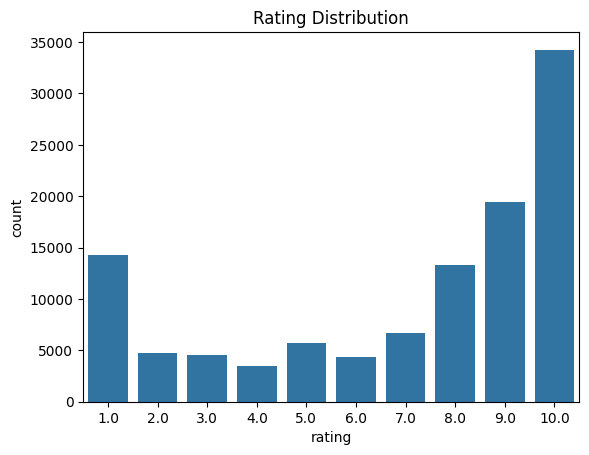

In [7]:
sns.countplot(x=train_df['rating'])
plt.title("Rating Distribution")
plt.show()

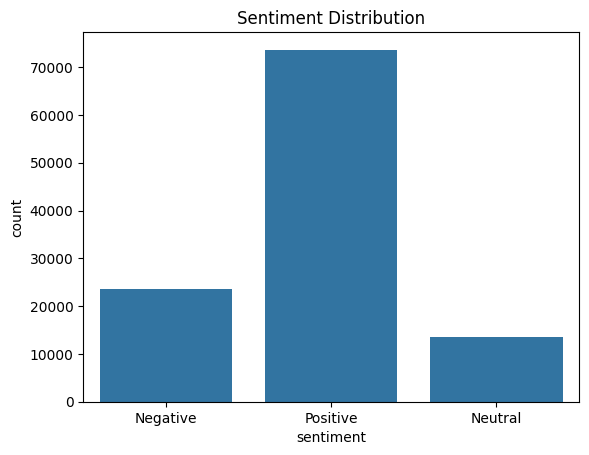

In [8]:
def create_sentiment(rating):
    if rating >= 7:
        return "Positive"
    elif rating >= 4:
        return "Neutral"
    else:
        return "Negative"

train_df['sentiment'] = train_df['rating'].apply(create_sentiment)
test_df['sentiment'] = test_df['rating'].apply(create_sentiment)

sns.countplot(x=train_df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

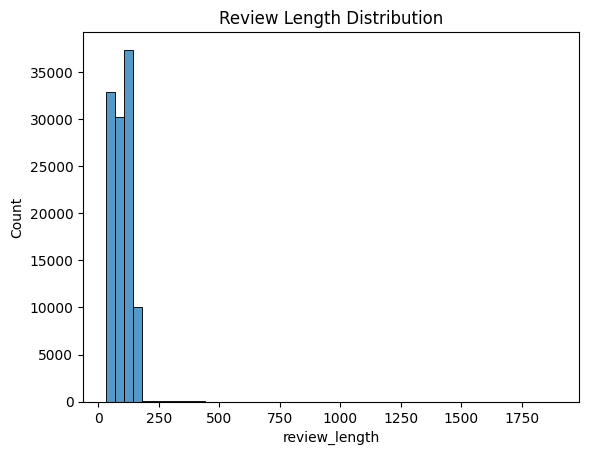

In [9]:
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

sns.histplot(train_df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

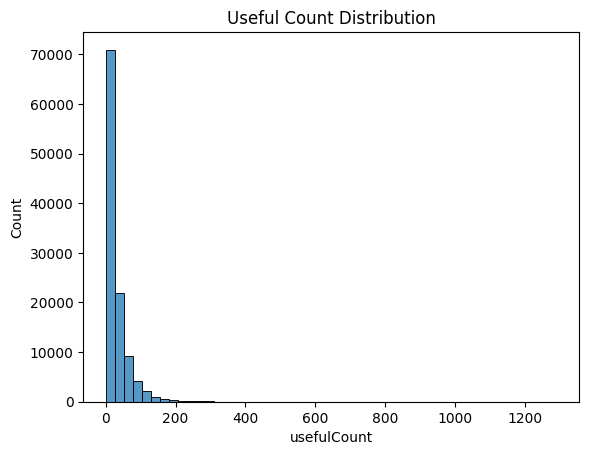

In [10]:
sns.histplot(train_df['usefulCount'], bins=50)
plt.title("Useful Count Distribution")
plt.show()

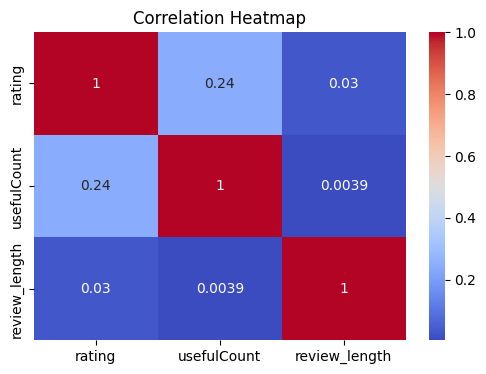

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(train_df[['rating','usefulCount','review_length']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# TEXT PREPROCESSING

In [12]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

train_df['clean_review'] = train_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\govin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\govin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


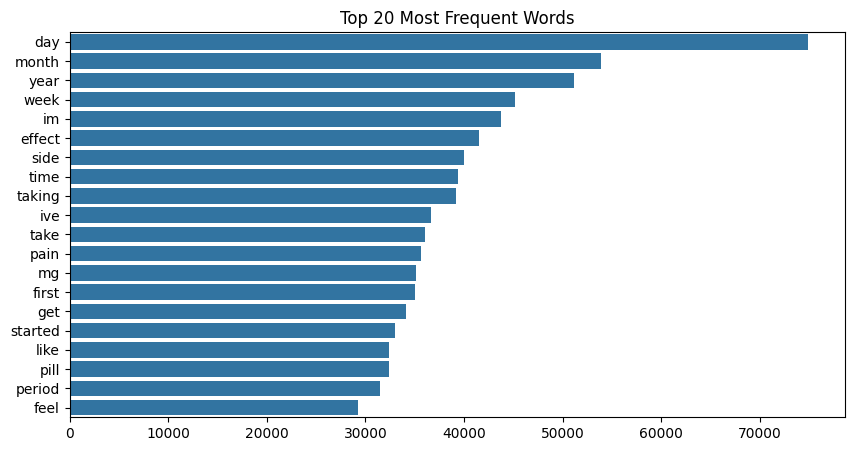

In [13]:
all_words = " ".join(train_df['clean_review']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Frequent Words")
plt.show()


# SENTIMENT ANALYSIS – TRADITIONAL ML

In [14]:
sentiment_results = []
tfidf = TfidfVectorizer(max_features=3000)
X_train = tfidf.fit_transform(train_df['clean_review'])
X_test = tfidf.transform(test_df['clean_review'])
y_train = train_df['sentiment']
y_test = test_df['sentiment']

In [15]:
smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Before SMOTE: Counter({'Positive': 73638, 'Negative': 23602, 'Neutral': 13571})
After SMOTE: Counter({'Negative': 73638, 'Positive': 73638, 'Neutral': 73638})


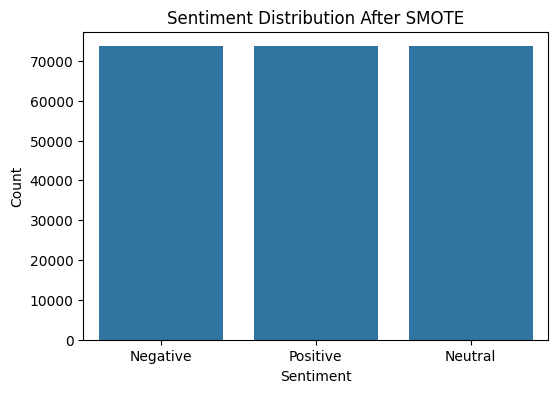

In [16]:
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_res))

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res)
plt.title("Sentiment Distribution After SMOTE")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=50)
}

sentiment_results = []
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    sentiment_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ])

# SENTIMENT – LSTM

C:\Users\govin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 161s 102ms/step - accuracy: 0.7588 - loss: 0.6123 - val_accuracy: 0.7719 - val_loss: 0.5707
Epoch 2/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 159s 102ms/step - accuracy: 0.8057 - loss: 0.4938 - val_accuracy: 0.7870 - val_loss: 0.5455
Epoch 3/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 159s 102ms/step - accuracy: 0.8410 - loss: 0.4115 - val_accuracy: 0.7929 - val_loss: 0.5474
Epoch 4/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 160s 103ms/step - accuracy: 0.8730 - loss: 0.3345 - val_accuracy: 0.8068 - val_loss: 0.5593
Epoch 5/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 168s 108ms/step - accuracy: 0.9036 - loss: 0.2625 - val_accuracy: 0.8149 - val_loss: 0.5741
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step
LSTM Classification Report
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      9993
           1       0.53      0.37      0.44      5706
           2       0.87      0.93      0.90     30409

    accuracy                           0.81  

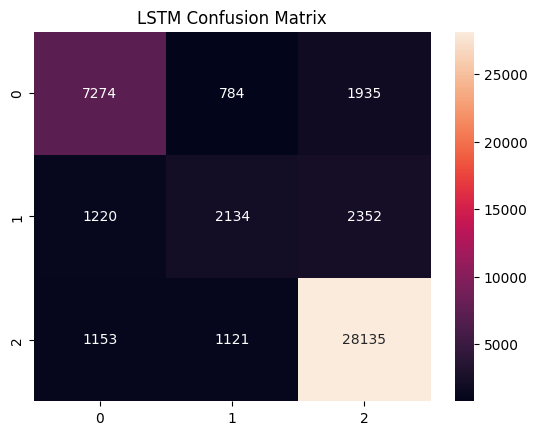

In [ ]:
tokenizer_sent = Tokenizer(num_words=10000)
tokenizer_sent.fit_on_texts(train_df['clean_review'])

X_train_seq = tokenizer_sent.texts_to_sequences(train_df['clean_review'])
X_test_seq = tokenizer_sent.texts_to_sequences(test_df['clean_review'])

X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000,128,input_length=200),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

history_lstm_sent = model_lstm.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

y_pred_lstm = model_lstm.predict(X_test_pad).argmax(axis=1)

print("LSTM Classification Report")
print(classification_report(y_test_enc, y_pred_lstm))

sns.heatmap(confusion_matrix(y_test_enc,y_pred_lstm), annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.show()

sentiment_results.append([
    "LSTM",
    accuracy_score(y_test_enc,y_pred_lstm),
    precision_score(y_test_enc,y_pred_lstm,average='macro'),
    recall_score(y_test_enc,y_pred_lstm,average='macro'),
    f1_score(y_test_enc,y_pred_lstm,average='macro')
])

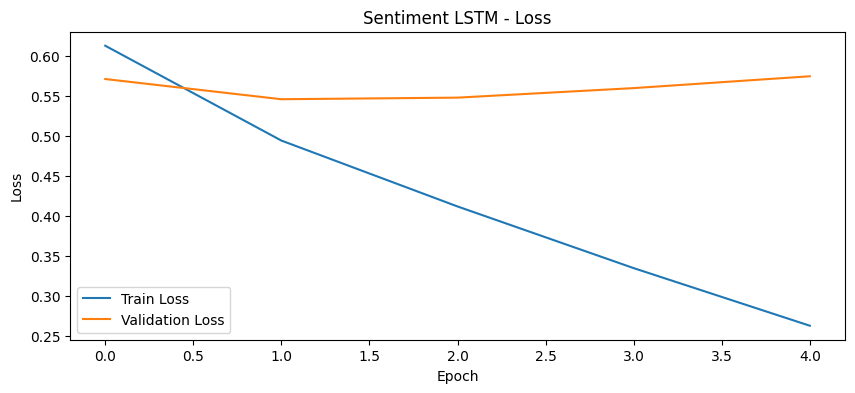

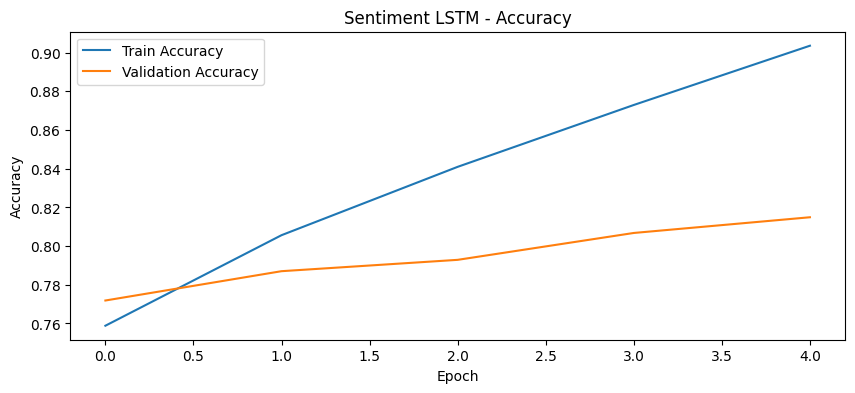

In [ ]:
# Loss Plot
plt.figure(figsize=(10,4))
plt.plot(history_lstm_sent.history['loss'], label='Train Loss')
plt.plot(history_lstm_sent.history['val_loss'], label='Validation Loss')
plt.title("Sentiment LSTM - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy Plot
plt.figure(figsize=(10,4))
plt.plot(history_lstm_sent.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm_sent.history['val_accuracy'], label='Validation Accuracy')
plt.title("Sentiment LSTM - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#SENTIMENT – BERT

In [ ]:
bert_train_df = train_df.sample(6000, random_state=42).reset_index(drop=True)
bert_test_df = test_df.sample(1500, random_state=42).reset_index(drop=True)

# Encode labels
le = LabelEncoder()
y_train_bert = le.fit_transform(bert_train_df['sentiment'])
y_test_bert = le.transform(bert_test_df['sentiment'])
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
# Load tokenizer
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = BertDataset(
    bert_train_df['review'].values,
    y_train_bert,
    tokenizer_bert
)
test_dataset = BertDataset(
    bert_test_df['review'].values,
    y_test_bert,
    tokenizer_bert
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

# TRAIN
train_losses = []
train_accuracies = []
for epoch in range(1):
    model_bert.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")


C:\Users\govin\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\govin\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Classification Report
              precision    recall  f1-score   support

           0       0.56      0.87      0.68       345
           1       0.20      0.01      0.01       184
           2       0.88      0.87      0.87       971

    accuracy                           0.76      1500
   macro avg       0.55      0.58      0.52      1500
weighted avg       0.72      0.76      0.72      1500



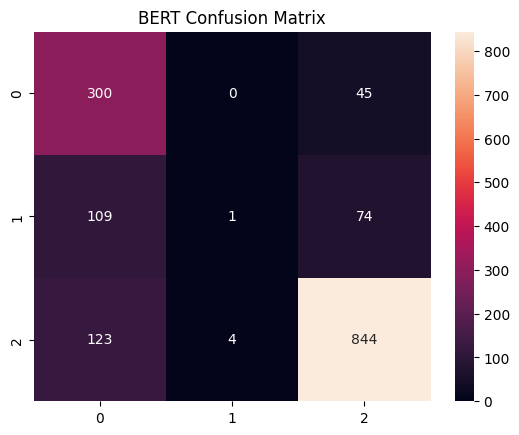

In [ ]:
# EVALUATION
model_bert.eval()
predictions = []
true_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("BERT Classification Report")
print(classification_report(true_labels, predictions))
sns.heatmap(confusion_matrix(true_labels, predictions),
            annot=True, fmt='d')
plt.title("BERT Confusion Matrix")
plt.show()
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Calculate BERT Metrics
bert_accuracy  = accuracy_score(true_labels, predictions)
bert_precision = precision_score(true_labels, predictions, average='macro')
bert_recall    = recall_score(true_labels, predictions, average='macro')
bert_f1        = f1_score(true_labels, predictions, average='macro')
sentiment_results.append([
    "BERT",
    bert_accuracy,
    bert_precision,
    bert_recall,
    bert_f1
])

# SENTIMENT COMPARISON TABLE + BAR CHART

          Model  Accuracy  Precision    Recall        F1
0      Logistic  0.690618   0.595338  0.634111  0.600534
1           SVM  0.690401   0.590924  0.629940  0.597814
2  RandomForest  0.848248   0.849496  0.723172  0.767330
3          LSTM  0.808515   0.705371  0.683006  0.692945
4          BERT  0.763333   0.546779  0.581402  0.522512


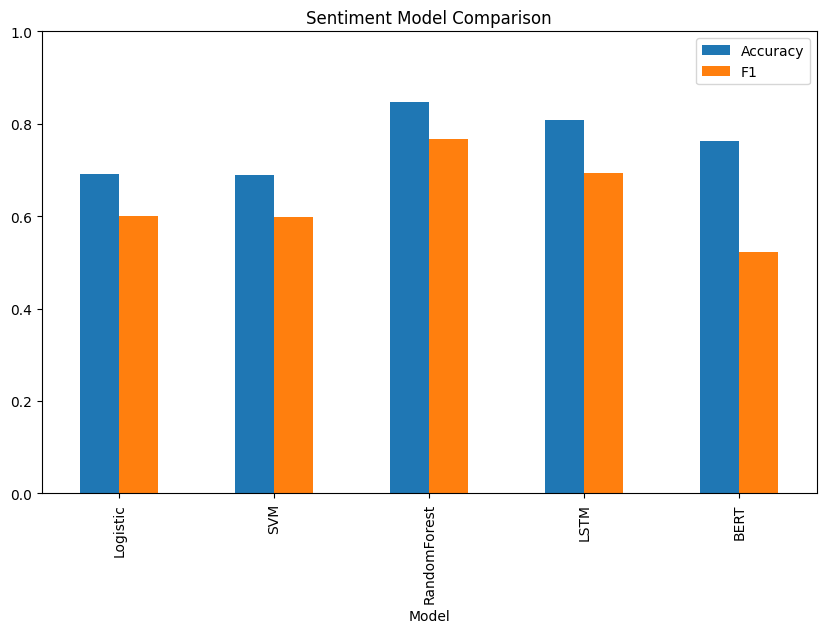

In [ ]:
sentiment_df = pd.DataFrame(
    sentiment_results,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)
print(sentiment_df)
sentiment_df.set_index("Model")[["Accuracy","F1"]].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title("Sentiment Model Comparison")
plt.ylim(0,1)
plt.show()

# ADR DETECTION

In [ ]:
# Create ADR Label
adr_keywords = ["nausea","vomiting","headache","dizziness","rash","fatigue"]

def detect_adr(text):
    text = str(text).lower()
    for word in adr_keywords:
        if word in text:
            return 1
    return 0

train_df['adr_label'] = train_df['review'].apply(detect_adr)
test_df['adr_label'] = test_df['review'].apply(detect_adr)

ADR Label Distribution (Train):
adr_label
0    89948
1    20863
Name: count, dtype: int64


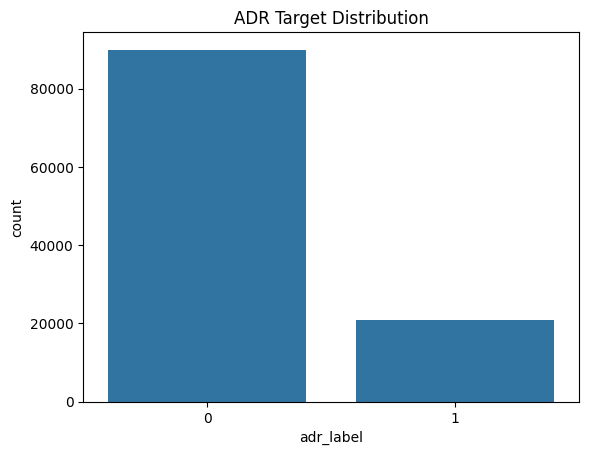

In [ ]:
# Check Target Balance
print("ADR Label Distribution (Train):")
print(train_df['adr_label'].value_counts())

sns.countplot(x=train_df['adr_label'])
plt.title("ADR Target Distribution")
plt.show()

In [ ]:
# Balance the Training Data
adr_class_0 = train_df[train_df['adr_label'] == 0]
adr_class_1 = train_df[train_df['adr_label'] == 1]

# Downsample majority class
adr_class_0_down = resample(
    adr_class_0,
    replace=False,
    n_samples=len(adr_class_1),
    random_state=42
)

train_df_balanced = pd.concat([adr_class_0_down, adr_class_1])
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42)

print("After Balancing:")
print(train_df_balanced['adr_label'].value_counts())

After Balancing:
adr_label
0    20863
1    20863
Name: count, dtype: int64


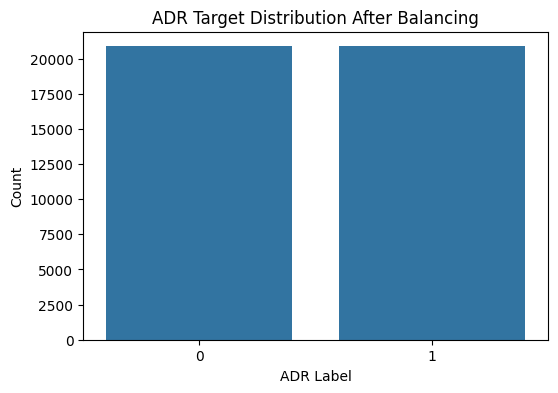

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=train_df_balanced['adr_label'])
plt.title("ADR Target Distribution After Balancing")
plt.xlabel("ADR Label")
plt.ylabel("Count")
plt.show()

In [ ]:
tfidf_adr = TfidfVectorizer(max_features=3000)

X_train_adr = tfidf_adr.fit_transform(train_df_balanced['clean_review'])
X_test_adr = tfidf_adr.transform(test_df['clean_review'])

y_train_adr = train_df_balanced['adr_label']
y_test_adr = test_df['adr_label']

# TRADITIONAL ML MODELS FOR ADR DETECTION

#LOGISTIC REGRESSION – ADR

Logistic Regression - ADR
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     37351
           1       1.00      0.96      0.98      8757

    accuracy                           0.99     46108
   macro avg       1.00      0.98      0.99     46108
weighted avg       0.99      0.99      0.99     46108



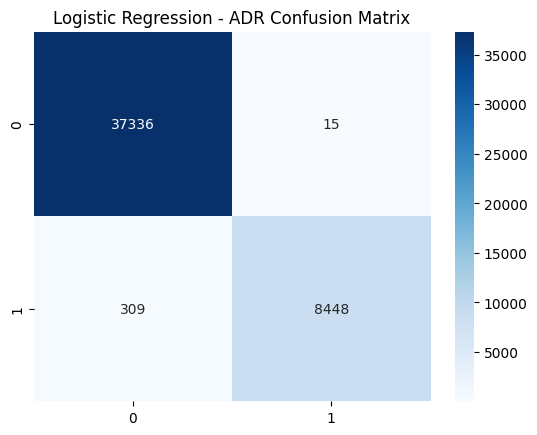

In [ ]:
adr_log = LogisticRegression(max_iter=1000)
adr_log.fit(X_train_adr, y_train_adr)

y_pred_log_adr = adr_log.predict(X_test_adr)

print("Logistic Regression - ADR")
print(classification_report(y_test_adr, y_pred_log_adr))

sns.heatmap(confusion_matrix(y_test_adr, y_pred_log_adr),
            annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - ADR Confusion Matrix")
plt.show()

#SVM – ADR

SVM - ADR
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37351
           1       1.00      0.98      0.99      8757

    accuracy                           1.00     46108
   macro avg       1.00      0.99      0.99     46108
weighted avg       1.00      1.00      1.00     46108



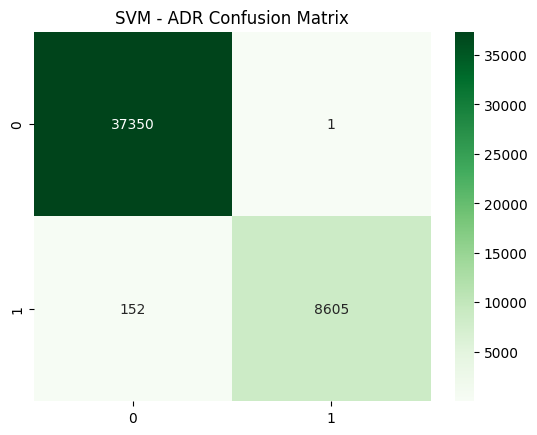

In [ ]:
adr_svm = LinearSVC()
adr_svm.fit(X_train_adr, y_train_adr)

y_pred_svm_adr = adr_svm.predict(X_test_adr)

print("SVM - ADR")
print(classification_report(y_test_adr, y_pred_svm_adr))

sns.heatmap(confusion_matrix(y_test_adr, y_pred_svm_adr),
            annot=True, fmt='d', cmap='Greens')
plt.title("SVM - ADR Confusion Matrix")
plt.show()

# RANDOM FOREST – ADR

Random Forest - ADR
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     37351
           1       0.97      0.99      0.98      8757

    accuracy                           0.99     46108
   macro avg       0.99      0.99      0.99     46108
weighted avg       0.99      0.99      0.99     46108



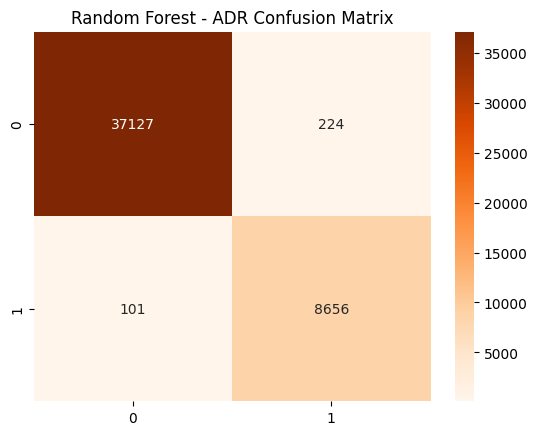

In [ ]:
adr_rf = RandomForestClassifier(n_estimators=100, random_state=42)
adr_rf.fit(X_train_adr, y_train_adr)

y_pred_rf_adr = adr_rf.predict(X_test_adr)

print("Random Forest - ADR")
print(classification_report(y_test_adr, y_pred_rf_adr))

sns.heatmap(confusion_matrix(y_test_adr, y_pred_rf_adr),
            annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest - ADR Confusion Matrix")
plt.show()

# LSTM – ADR

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 164s 274ms/step - accuracy: 0.8635 - loss: 0.2756 - val_accuracy: 0.9909 - val_loss: 0.0440
Epoch 2/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 202s 274ms/step - accuracy: 0.9899 - loss: 0.0492 - val_accuracy: 0.9803 - val_loss: 0.0736
Epoch 3/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 196s 265ms/step - accuracy: 0.9922 - loss: 0.0355 - val_accuracy: 0.9919 - val_loss: 0.0446
Epoch 4/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 203s 267ms/step - accuracy: 0.9943 - loss: 0.0235 - val_accuracy: 0.9926 - val_loss: 0.0350
Epoch 5/5
587/587 ━━━━━━━━━━━━━━━━━━━━ 157s 267ms/step - accuracy: 0.9962 - loss: 0.0137 - val_accuracy: 0.9933 - val_loss: 0.0369
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step
LSTM - ADR
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37351
           1       0.99      0.99      0.99      8757

    accuracy                           1.00     46108
   macro avg       0.99      0.99      0.99     46108
weighted avg     

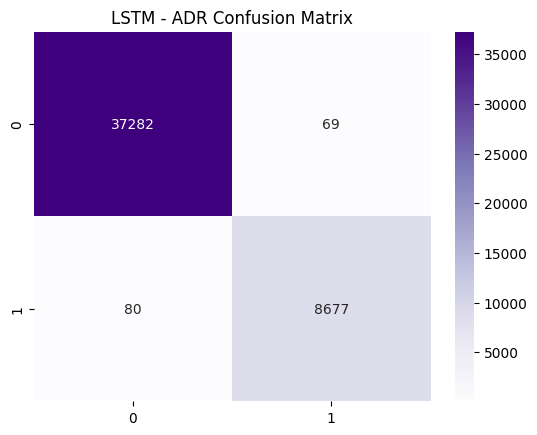

In [ ]:
# Tokenizer
tokenizer_adr = Tokenizer(num_words=10000)
tokenizer_adr.fit_on_texts(train_df_balanced['clean_review'])

X_train_seq = tokenizer_adr.texts_to_sequences(train_df_balanced['clean_review'])
X_test_seq = tokenizer_adr.texts_to_sequences(test_df['clean_review'])

X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

y_train_lstm = y_train_adr.values
y_test_lstm = y_test_adr.values

# Model
model_lstm_adr = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 128, input_length=200),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_lstm_adr.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_adr = model_lstm_adr.fit(
    X_train_pad,
    y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

y_pred_lstm_adr = (model_lstm_adr.predict(X_test_pad) > 0.5).astype(int)

print("LSTM - ADR")
print(classification_report(y_test_lstm, y_pred_lstm_adr))

sns.heatmap(confusion_matrix(y_test_lstm, y_pred_lstm_adr),
            annot=True, fmt='d', cmap='Purples')
plt.title("LSTM - ADR Confusion Matrix")
plt.show()

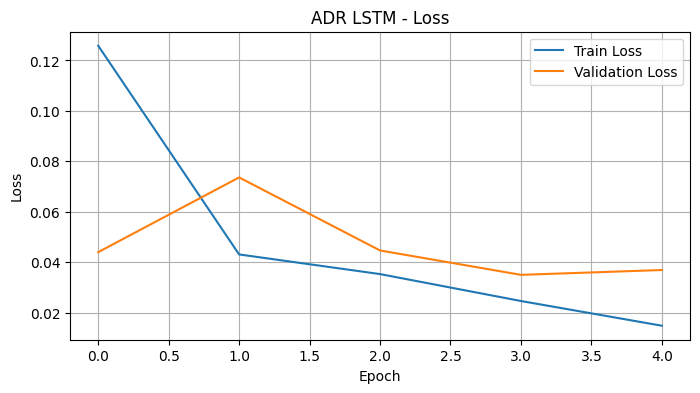

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm_adr.history['loss'], label='Train Loss')
plt.plot(history_lstm_adr.history['val_loss'], label='Validation Loss')
plt.title("ADR LSTM - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

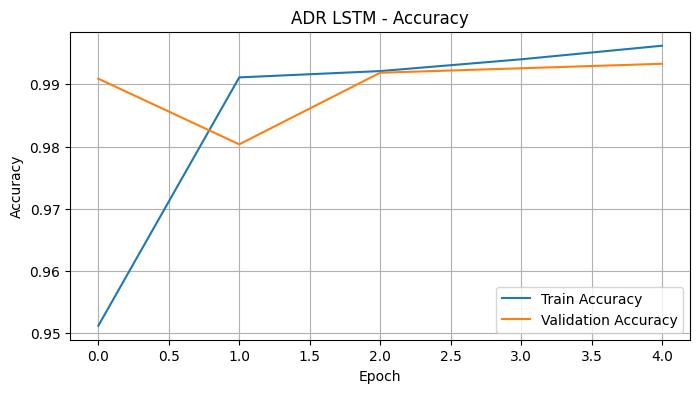

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm_adr.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm_adr.history['val_accuracy'], label='Validation Accuracy')
plt.title("ADR LSTM - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# BERT – ADR

In [ ]:
adr_train_small = train_df_balanced.sample(5000, random_state=42).reset_index(drop=True)
adr_test_small = test_df.sample(1500, random_state=42).reset_index(drop=True)
y_train_small = adr_train_small['adr_label'].values
y_test_small = adr_test_small['adr_label'].values

class BertDatasetADR(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = BertDatasetADR(
    adr_train_small['review'].values,
    y_train_small,
    tokenizer_bert
)

test_dataset = BertDatasetADR(
    adr_test_small['review'].values,
    y_test_small,
    tokenizer_bert
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

model_bert_adr = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert_adr.to(device)
optimizer = torch.optim.AdamW(model_bert_adr.parameters(), lr=2e-5)

# Training
for epoch in range(1):
    model_bert_adr.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_bert_adr(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        preds_batch = torch.argmax(outputs.logits, dim=1)
        correct += (preds_batch == labels).sum().item()
        total += labels.size(0)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")



BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.2648


In [ ]:
# Evaluate
model_bert_adr.eval()
preds, true = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model_bert_adr(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        predictions = torch.argmax(outputs.logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        true.extend(labels.cpu().numpy())

print("BERT - ADR")
print(classification_report(true, preds))

gc.collect()
torch.cuda.empty_cache()

BERT - ADR
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1221
           1       1.00      0.87      0.93       279

    accuracy                           0.98      1500
   macro avg       0.99      0.94      0.96      1500
weighted avg       0.98      0.98      0.98      1500



#  ADR COMPARISON TABLE

In [ ]:
adr_comparison = pd.DataFrame({
    "Model": ["Logistic", "SVM", "Random Forest", "LSTM", "BERT"],
    "Accuracy": [
        accuracy_score(y_test_adr, y_pred_log_adr),
        accuracy_score(y_test_adr, y_pred_svm_adr),
        accuracy_score(y_test_adr, y_pred_rf_adr),
        accuracy_score(y_test_lstm, y_pred_lstm_adr),
        accuracy_score(true, preds)
    ],
    "Precision": [
        precision_score(y_test_adr, y_pred_log_adr),
        precision_score(y_test_adr, y_pred_svm_adr),
        precision_score(y_test_adr, y_pred_rf_adr),
        precision_score(y_test_lstm, y_pred_lstm_adr),
        precision_score(true, preds)
    ],
    "Recall": [
        recall_score(y_test_adr, y_pred_log_adr),
        recall_score(y_test_adr, y_pred_svm_adr),
        recall_score(y_test_adr, y_pred_rf_adr),
        recall_score(y_test_lstm, y_pred_lstm_adr),
        recall_score(true, preds)
    ],
    "F1 Score": [
        f1_score(y_test_adr, y_pred_log_adr),
        f1_score(y_test_adr, y_pred_svm_adr),
        f1_score(y_test_adr, y_pred_rf_adr),
        f1_score(y_test_lstm, y_pred_lstm_adr),
        f1_score(true, preds)
    ]
})

print(adr_comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0       Logistic  0.992973   0.998228  0.964714  0.981185
1            SVM  0.996682   0.999884  0.982642  0.991188
2  Random Forest  0.992951   0.974775  0.988466  0.981573
3           LSTM  0.996768   0.992111  0.990864  0.991487
4           BERT  0.976000   1.000000  0.870968  0.931034


# ADR PERFORMANCE BAR CHART

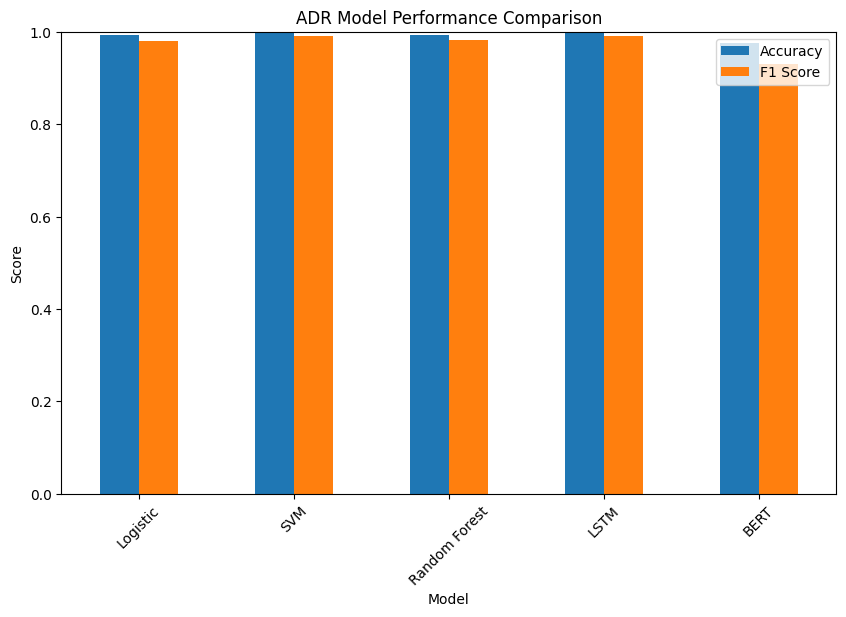

In [ ]:
adr_comparison.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("ADR Model Performance Comparison")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import nbformat
file = "sentiment-adr-detection-drug-reviews.ipynb"
nb = nbformat.read(file, as_version=4)
# Remove broken widget metadata ONLY
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]
nbformat.write(nb, file)

print("DONE: Notebook fixed without removing outputs")